# plotting connectomes

in this tutorial, you will see how to use yabplot to visualise connectomes i.e. graphs consisting of nodes and edges from data matrices.

**why plot connectomes?** often when you would like to visualise the relationship between different brain regions, then single regional data is not enough. the field of connectomics often studies relationships between brain regions and often visualise the brain as a vast graph where regions are shown as nodes and their relationships as edges.

### inputs and outputs

1. **data matrix (`numpy.ndarray` or `pandas.DataFrame`):** an n x n shaped matrix.

finally, we can pass this matrix into `plot_connectome` to visualize the matrix in a 3D rendered scene as a graph.

In [1]:
import pandas as pd
import yabplot as yab
import matplotlib.pyplot as plt

data = pd.read_csv('/Users/to8050an/Developer/yabplot_miscfiles/test_data/hcp_connectivity/funcMatrix_ctx_schaefer_400.csv', header=None).to_numpy()
labels = list(pd.read_csv('/Users/to8050an/Developer/yabplot_miscfiles/test_data/hcp_connectivity/funcLabels_ctx_schaefer_400.csv').columns)
df = pd.DataFrame(data, index=labels, columns=labels)
df

,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,7Networks_LH_Vis_10,...,7Networks_RH_Default_PFCdPFCm_13,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2,7Networks_RH_Default_pCunPCC_3,7Networks_RH_Default_pCunPCC_4,7Networks_RH_Default_pCunPCC_5,7Networks_RH_Default_pCunPCC_6,7Networks_RH_Default_pCunPCC_7,7Networks_RH_Default_pCunPCC_8,7Networks_RH_Default_pCunPCC_9
7Networks_LH_Vis_1,0.000000,0.248430,0.383680,0.297230,0.301150,0.30694,0.124500,0.365270,0.261410,0.218580,...,0.062431,0.18768,0.046968,0.16267,0.100340,0.12387,0.100360,0.041825,0.086295,0.15960
7Networks_LH_Vis_2,0.248430,0.000000,0.184670,0.256660,0.184390,0.15954,0.206150,0.172160,0.175490,0.157310,...,0.026568,0.36570,0.071601,0.27566,0.185050,0.20589,0.172900,0.050208,0.125210,0.21362
7Networks_LH_Vis_3,0.383680,0.184670,0.000000,0.470760,0.602060,0.63561,0.141000,0.664050,0.488640,0.390000,...,0.125560,0.17417,0.058647,0.17260,0.094387,0.11809,0.091927,0.079465,0.102520,0.20023
7Networks_LH_Vis_4,0.297230,0.256660,0.470760,0.000000,0.624720,0.40105,0.212380,0.430560,0.407430,0.543970,...,0.105960,0.24534,0.068197,0.24113,0.071932,0.10353,0.081813,0.068869,0.077668,0.23314
7Networks_LH_Vis_5,0.301150,0.184390,0.602060,0.624720,0.000000,0.60393,0.154300,0.559400,0.674580,0.591350,...,0.119660,0.20623,0.066630,0.20999,0.075629,0.10575,0.081727,0.077694,0.081771,0.21635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7Networks_RH_Default_pCunPCC_5,0.123870,0.205890,0.118090,0.103530,0.105750,0.14404,0.142250,0.104530,0.145230,0.104330,...,0.143020,0.45636,0.188770,0.48416,0.672120,0.00000,0.400730,0.217680,0.529040,0.28717
7Networks_RH_Default_pCunPCC_6,0.100360,0.172900,0.091927,0.081813,0.081727,0.13190,0.116020,0.071925,0.132100,0.065465,...,0.090063,0.34082,0.188370,0.36454,0.407170,0.40073,0.000000,0.267580,0.401820,0.28982
7Networks_RH_Default_pCunPCC_7,0.041825,0.050208,0.079465,0.068869,0.077694,0.11807,0.061815,0.072621,0.098202,0.067691,...,0.179760,0.13496,0.153040,0.22489,0.223450,0.21768,0.267580,0.000000,0.269030,0.17599
7Networks_RH_Default_pCunPCC_8,0.086295,0.125210,0.102520,0.077668,0.081771,0.14174,0.104180,0.094047,0.116840,0.070157,...,0.226070,0.29112,0.188120,0.37039,0.517750,0.52904,0.401820,0.269030,0.000000,0.34648


## 1. plot any subcortical or cortical atlas as a connectome

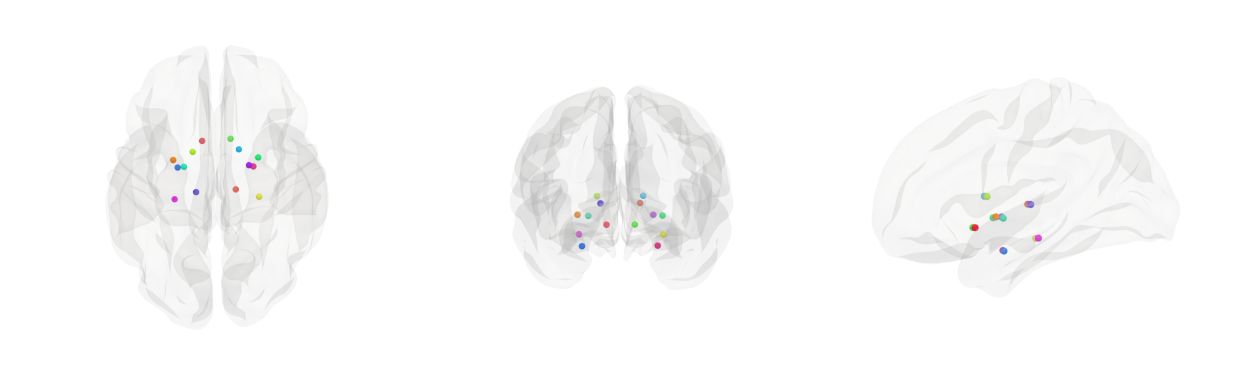

In [2]:
# plotting a an atlas without data
ax = yab.plot_connectome(
    atlas='aseg', # you can use all cortical and subcortical atlases
    views=['superior', 'posterior', 'left_lateral']
)

## 2. add matrix data corresponding to atlas

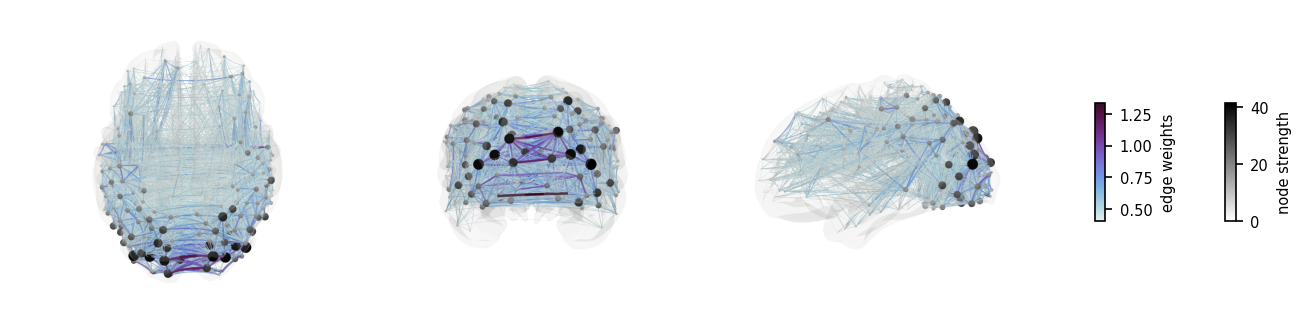

In [3]:
ax = yab.plot_connectome(
    matrix=df, # now lets add some data
    atlas='schaefer400',
    edge_cmap='dense',
    views=['superior', 'posterior', 'left_lateral']
)

## 3. many parameters to edit the visualised connectome

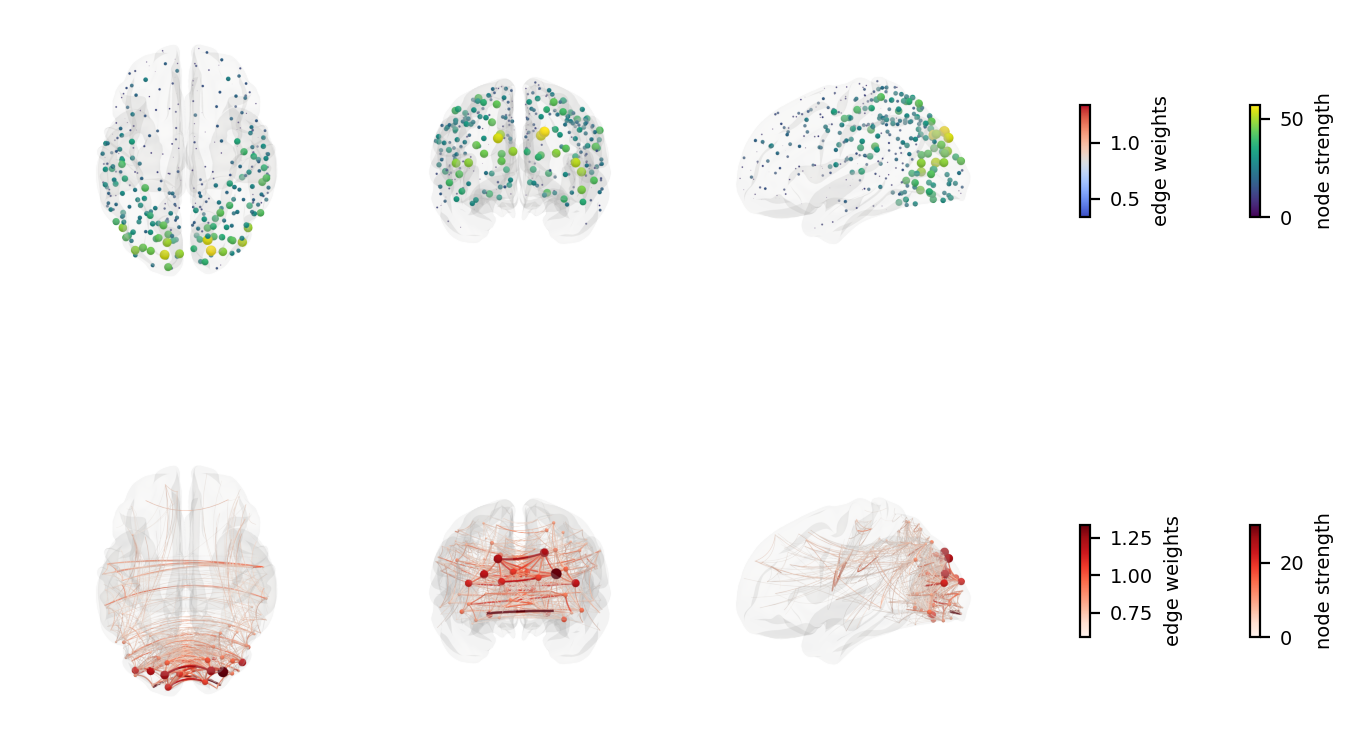

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), dpi=200)

# you can change a set of parameters, see below
axes[0] = yab.plot_connectome(
    matrix=df,
    ax=axes[0],
    atlas='schaefer400',
    edge_threshold='90%', 
    edge_alpha=0,
    node_cmap='viridis',
    views=['superior', 'posterior', 'left_lateral'],
)

axes[1] = yab.plot_connectome(
    matrix=df,
    ax=axes[1],
    atlas='schaefer400',
    edge_threshold='99%',
    edge_alpha=1,
    edge_thickness='weight',
    edge_cmap='Reds',
    edge_curve=0.3,
    node_size='strength',
    node_color='strength',
    node_cmap='Reds',
    views=['superior', 'posterior', 'left_lateral'],
    directed=False
)